In [1]:
!pip install xgboost


In [2]:
!pip install statsmodels


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install dtreeviz --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 1.4 MB/s eta 0:00:00


In [5]:
!pip install cairosvg


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.6 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from dtreeviz import dtreeviz
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from dtreeviz import model
from cairosvg import svg2png
from IPython.display import Image, display

from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 110)
pd.set_option("display.max_rows", 25970)


In [7]:
# Read an Excel file into a DataFrame using pandas

df = pd.read_excel("/content/drive/MyDrive/UMBCDATA/RT2733808 Financial aid stdnt Success analysis Final Sp2025.xlsx")


In [8]:
# Display the first 5 rows of the DataFrame to get a quick look at the data
df.head()


,StudentKey,EmployeeID,MatricTermdescription,MatricAcademicYear,MatricStatusOfficialDescr,MatricGenderIPEDS,MatricIPEDSEthnicity,Zipcode,MatricResidence,Graduated,Yrs_To_Deg,Sem_To_Deg,Plan1_1,Plan1_2,Plan1_3,Plan1_4,Plan1_5,Plan1_6,Plan1_7,Plan1_8,Plan1_9,Plan1_10,Plan1_11,Plan1_12,Plan1_13,Plan1_14,Plan1_15,Plan1_16,Deg_8,Deg_10,Deg_12,LastSTEMType,LastrptgPlanShortDescr,Sem1_FTPT,Sem2_FTPT,Sem3_FTPT,Sem4_FTPT,Sem5_FTPT,Sem6_FTPT,Sem7_FTPT,Sem8_FTPT,Sem9_FTPT,Sem10_FTPT,Sem11_FTPT,Sem12_FTPT,Sem13_FTPT,Sem14_FTPT,Sem15_FTPT,Sem16_FTPT,Same_STEM_1_2,Same_STEM_1_21,Same_STEM_1_3,Same_STEM_1_4,Same_STEM_1_5,Same_STEM_1_6,Same_STEM_1_7,Same_STEM_1_8,Same_STEM_1_9,Same_STEM_1_10,Same_STEM_1_11,Same_STEM_1_12,Same_STEM_1_13,Same_STEM_1_14,Same_STEM_1_15,Same_STEM_1_16,Degr4Sem,Degr5Sem,Degr6Sem,Degr7Sem,Degr8Sem,Degr9Sem,Degr10Sem,Degr11Sem,Degr12Sem,Degr13Sem,Degr14Sem,Degr15Sem,Degr16Sem,Y1Need,Y2Need,Y3Need,Y4Need,Y5Need,Y6Need,Y1GrantAmount,Y2GrantAmount,Y3GrantAmount,Y4GrantAmount,Y5GrantAmount,Y6GrantAmount,Y1MeritAmount,Y2MeritAmount,Y3MeritAmount,Y4MeritAmount,Y5MeritAmount,Y6MeritAmount,Y1ScholarProgram,Y1ProgramAmount,Y2ScholarProgram,Y2ProgramAmount,Y3ScholarProgram,Y3ProgramAmount,Y4ScholarProgram,Y4ProgramAmount,Y5ScholarProgram,Y5ProgramAmount,Y6ScholarProgram,Y6ProgramAmount
0,282696,3000000818,Fall 2012,2013,New Freshman,Female,Black/African American,21163,On Campus,Yes,4.0,8.0,Mathematics,Mathematics,Mathematics,Mathematics,Mathematics,Mathematics,Mathematics,Mathematics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,STEM Plan,Mathematics,FT,FT,FT,FT,FT,FT,FT,FT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Medium,Medium,Medium,Medium,No Fafsa,No Fafsa,0.0,0.0,0.0,0.0,0.0,0.0,15000.0,15000.0,15000.0,15000.0,0.0,0.0,MEYERHOFF,15000,MEYERHOFF,15000,MEYERHOFF,15000,MEYERHOFF,15000,NaN,0,NaN,0
1,294772,3000158695,Fall 2012,2013,New Freshman,Male,White,21904,On Campus,Yes,4.0,8.0,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Chemistry,Chemistry,Chemistry,Chemistry,Chemistry,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,STEM Plan,Chemistry,FT,FT,FT,FT,FT,FT,FT,FT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,No Fafsa,No Fafsa,No Fafsa,No Fafsa,No Fafsa,No Fafsa,0.0,0.0,0.0,0.0,0.0,0.0,18000.0,18000.0,18000.0,15000.0,0.0,0.0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2,217735,3000173487,Fall 2012,2013,New Freshman,Female,White,21042,On Campus,Yes,4.0,8.0,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,STEM Plan,Mech Eng,FT,FT,FT,FT,FT,FT,FT,FT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,Medium,No Fafsa,No Fafsa,No Fafsa,No Fafsa,No Fafsa,0.0,0.0,0.0,0.0,0.0,0.0,15000.0,15000.0,15000.0,15000.0,0.0,0.0,CWIT,15000,CWIT,15000,CWIT,15000,CWIT,15000,NaN,0,NaN,0
3,305144,3000175797,Fall 2012,2013,New Freshman,Male,Black/African American,20794,On Campus,Yes,4.0,8.0,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,Mech Eng,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,STEM Plan,Mech Eng,FT,FT,FT,FT,FT,FT,FT,FT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,No Fafsa,No Fafsa,No Fafsa,No Fafsa,No Fafsa,No Fafsa,0.0,0.0,0.0,0.0,0.0,0.0,15000.0,15000.0,15000.0,15000.0,0.0,0.0,MEYERHOFF,15000,MEYERHOFF,15000,MEYERHOFF,15000,MEYERHOFF,15000,NaN,0,NaN,0
4,304109,3000183293,Fall 2012,2013,New Freshman,Male,White,20619,On Campus,Yes,4.0,8.0,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,Bioc & Mol Biol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,STEM Plan,Bioc & Mol Biol,FT,FT,FT,FT,FT,FT,FT,FT,NaN,NaN,Na

In [9]:
# Returns (rows, columns) of the DataFrame
df.shape


(25960, 108)

# Output: (25960, 108) → 25,960 rows and 108 columns

In [10]:
# Filter only 'New Freshman' students
freshman_df = df[df['MatricStatusOfficialDescr'] == 'New Freshman']

print(freshman_df.shape)

print(freshman_df.head())


(15954, 108)
   StudentKey  EmployeeID MatricTermdescription  MatricAcademicYear  \
0      282696  3000000818             Fall 2012                2013   
1      294772  3000158695             Fall 2012                2013   
2      217735  3000173487             Fall 2012                2013   
3      305144  3000175797             Fall 2012                2013   
4      304109  3000183293             Fall 2012                2013   

  MatricStatusOfficialDescr MatricGenderIPEDS    MatricIPEDSEthnicity Zipcode  \
0              New Freshman            Female  Black/African American   21163   
1              New Freshman              Male                   White   21904   
2              New Freshman            Female                   White   21042   
3              New Freshman              Male  Black/African American   20794   
4              New Freshman              Male                   White   20619   

  MatricResidence Graduated  Yrs_To_Deg  Sem_To_Deg          Plan1_1  \
0

In [11]:
# Define specific columns to keep from 3 patterns: Plan1_, Sem, and Same_STEM_1_
plan_keep = [f'Plan1_{i}' for i in range(1, 9)]       # Plan1_1 to Plan1_8
sem_keep = [f'Sem{i}_FTPT' for i in range(1, 9)]      # Sem1_FTPT to Sem8_FTPT
stem_keep = [f'Same_STEM_1_{i}' for i in range(2, 9)] # Same_STEM_1_2 to Same_STEM_1_8


# Flatten all columns to keep from these 3 groups
keep_these = set(plan_keep + sem_keep + stem_keep)

# Now include all columns NOT related to these 3 groups (Plan1_, Sem, Same_STEM)
# unless they're in the keep list
final_columns = [col for col in freshman_df.columns
                 if (not col.startswith(('Plan1_', 'Sem', 'Same_STEM_1_')) or col in keep_these)]

# Create the trimmed DataFrame
freshman_trimmed_df = freshman_df[final_columns]

# Display result
print(freshman_trimmed_df.shape)
print(freshman_trimmed_df.head())


(15954, 82)
   StudentKey  EmployeeID MatricTermdescription  MatricAcademicYear  \
0      282696  3000000818             Fall 2012                2013   
1      294772  3000158695             Fall 2012                2013   
2      217735  3000173487             Fall 2012                2013   
3      305144  3000175797             Fall 2012                2013   
4      304109  3000183293             Fall 2012                2013   

  MatricStatusOfficialDescr MatricGenderIPEDS    MatricIPEDSEthnicity Zipcode  \
0              New Freshman            Female  Black/African American   21163   
1              New Freshman              Male                   White   21904   
2              New Freshman            Female                   White   21042   
3              New Freshman              Male  Black/African American   20794   
4              New Freshman              Male                   White   20619   

  MatricResidence Graduated  Yrs_To_Deg          Plan1_1          Plan1_2 

# **Cleaning Data**

In [12]:
# Calculate percentage of missing values for each column
null_percentage = (freshman_trimmed_df.isnull().sum() / len(freshman_trimmed_df)) * 100

# Keep only columns with missing values, sorted from highest to lowest
null_percentage = null_percentage[null_percentage > 0].sort_values(ascending=False)

# Show columns with missing data and their % of nulls
print(null_percentage)


Y6ScholarProgram    99.981196
Y5ScholarProgram    99.492290
Y4ScholarProgram    95.906983
Y3ScholarProgram    95.211232
Y2ScholarProgram    93.594083
Y1ScholarProgram    92.873261
Degr16Sem           66.798295
Degr15Sem           60.028833
Degr14Sem           59.922277
Yrs_To_Deg          53.955121
Degr13Sem           51.886674
Deg_12              51.798922
Degr12Sem           51.798922
Plan1_8             50.338473
Sem8_FTPT           50.325937
Sem7_FTPT           46.333208
Plan1_7             46.333208
Degr11Sem           44.170741
Deg_10              44.120597
Degr10Sem           44.120597
Plan1_6             36.906105
Sem6_FTPT           36.906105
Degr9Sem            36.530024
Deg_8               36.429735
Degr8Sem            36.429735
Sem5_FTPT           35.213740
Plan1_5             35.213740
Degr7Sem            27.748527
Same_STEM_1_8       27.748527
Degr6Sem            27.598095
Same_STEM_1_7       27.598095
Plan1_4             25.172371
Sem4_FTPT           25.172371
Sem3_FTPT 

In [13]:
# Find column names with more than 50% missing values
columns_to_drop = null_percentage[null_percentage > 50].index

# Drop those columns from the DataFrame
freshman_cleaned_df = freshman_trimmed_df.drop(columns=columns_to_drop)

# Show which columns were dropped and new shape of the DataFrame
print(f"Columns dropped: {list(columns_to_drop)}")
print(freshman_cleaned_df.shape)


Columns dropped: ['Y6ScholarProgram', 'Y5ScholarProgram', 'Y4ScholarProgram', 'Y3ScholarProgram', 'Y2ScholarProgram', 'Y1ScholarProgram', 'Degr16Sem', 'Degr15Sem', 'Degr14Sem', 'Yrs_To_Deg', 'Degr13Sem', 'Deg_12', 'Degr12Sem', 'Plan1_8', 'Sem8_FTPT']
(15954, 67)


In [14]:
# Count missing values per column
null_counts = freshman_cleaned_df.isnull().sum()

# Calculate missing value percentages
null_percentages = (null_counts / len(freshman_cleaned_df)) * 100

# Create a summary DataFrame of null counts and percentages
null_report = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage (%)': null_percentages
})

# Keep only columns with missing values, sorted by percentage descending
null_report = null_report[null_report['Null Count'] > 0].sort_values(by='Null Percentage (%)', ascending=False)

# Show the null summary
print(null_report)


               Null Count  Null Percentage (%)
Plan1_7              7392            46.333208
Sem7_FTPT            7392            46.333208
Degr11Sem            7047            44.170741
Degr10Sem            7039            44.120597
Deg_10               7039            44.120597
Plan1_6              5888            36.906105
Sem6_FTPT            5888            36.906105
Degr9Sem             5828            36.530024
Deg_8                5812            36.429735
Degr8Sem             5812            36.429735
Sem5_FTPT            5618            35.213740
Plan1_5              5618            35.213740
Same_STEM_1_8        4427            27.748527
Degr7Sem             4427            27.748527
Degr6Sem             4403            27.598095
Same_STEM_1_7        4403            27.598095
Sem4_FTPT            4016            25.172371
Plan1_4              4016            25.172371
Plan1_3              3327            20.853704
Sem3_FTPT            3327            20.853704
Degr5Sem     

In [15]:
# Fill Plan and Semester columns with 'NA'
plan_sem_cols = [col for col in freshman_cleaned_df.columns if col.startswith('Plan1_') or col.startswith('Sem')]
freshman_cleaned_df[plan_sem_cols] = freshman_cleaned_df[plan_sem_cols].fillna('NA')

# Fill degree-related columns with 0
deg_cols = [col for col in freshman_cleaned_df.columns if col.startswith('Degr') or col.startswith('Deg_')]
freshman_cleaned_df[deg_cols] = freshman_cleaned_df[deg_cols].fillna(0)

# Fill Same_STEM columns with 0
stem_cols = [col for col in freshman_cleaned_df.columns if col.startswith('Same_STEM_')]
freshman_cleaned_df[stem_cols] = freshman_cleaned_df[stem_cols].fillna(0)

# Fill missing Zipcode values with the most frequent one (mode)
if freshman_cleaned_df['Zipcode'].isnull().sum() > 0:
    zipcode_mode = freshman_cleaned_df['Zipcode'].mode()[0]
    freshman_cleaned_df['Zipcode'] = freshman_cleaned_df['Zipcode'].fillna(zipcode_mode)


In [16]:
null_report = freshman_cleaned_df.isnull().sum()
null_report = null_report[null_report > 0]
print(null_report)


Series([], dtype: int64)


In [17]:
# Create 'totalsupport' column as sum of all grant + merit amounts from Year 1 to Year 6
freshman_cleaned_df['totalsupport'] = freshman_cleaned_df.loc[:, 'Y1GrantAmount':'Y6MeritAmount'].sum(axis=1)

# Create 'supportedY1': 1 if student received any support in Year 1, else 0
freshman_cleaned_df['supportedY1'] = freshman_cleaned_df.apply(
    lambda x: 1 if (x['Y1GrantAmount'] + x['Y1MeritAmount']) != 0 else 0, axis=1
)

# Create 'supported': 1 if student received any support in any year, else 0
freshman_cleaned_df['supported'] = (freshman_cleaned_df['totalsupport'] != 0).astype(int)

# Count how many students were supported vs not supported
support_counts = freshman_cleaned_df[['supported']].value_counts()
print(support_counts)


supported
1            11970
0             3984
Name: count, dtype: int64


In [18]:
# Define financial need columns for Year 1 to Year 6
need_cols = [f'Y{i}Need' for i in range(1, 7)]

# Create 'In_Need': 'Yes' if any year shows High, Medium, or Low need; else 'No'
freshman_cleaned_df['In_Need'] = freshman_cleaned_df[need_cols].apply(
    lambda row: 'Yes' if any(val in ['High', 'Medium', 'Low'] for val in row) else 'No', axis=1
)

# Count how many students were ever in need vs not
print(freshman_cleaned_df['In_Need'].value_counts())


In_Need
Yes    13151
No      2803
Name: count, dtype: int64


In [19]:
# Define columns for merit-based financial aid (Year 1 to 6)
merit_cols = [f'Y{i}MeritAmount' for i in range(1, 7)]

# Define columns for scholarship program amounts (Year 1 to 6)
program_cols = [f'Y{i}ProgramAmount' for i in range(1, 7)]

# Create 'Got_Merit': 'Yes' if total merit aid > 0, else 'No'
freshman_cleaned_df['Got_Merit'] = freshman_cleaned_df[merit_cols].sum(axis=1).apply(
    lambda x: 'Yes' if x > 0 else 'No'
)

# Create 'Got_Scholarship_Program': 'Yes' if total scholarship program aid > 0, else 'No'
freshman_cleaned_df['Got_Scholar'] = freshman_cleaned_df[program_cols].sum(axis=1).apply(
    lambda x: 'Yes' if x > 0 else 'No'
)


In [20]:
# Get all semester columns that indicate full-time or part-time status
sem_ftpt_cols = [col for col in freshman_cleaned_df.columns if col.startswith('Sem') and col.endswith('_FTPT')]

# Create 'Is_FullTime': 'Yes' if student was full-time ('FT') in any semester, else 'No'
freshman_cleaned_df['Is_FullTime'] = freshman_cleaned_df[sem_ftpt_cols].apply(
    lambda row: 'Yes' if 'FT' in row.values else 'No', axis=1
)


In [21]:
# 1. Identify Plan Columns

# Create a list of major-related columns Plan1_1 to Plan1_7 (if they exist in the DataFrame)
plan_cols = [f'Plan1_{i}' for i in range(1, 8) if f'Plan1_{i}' in freshman_cleaned_df.columns]


# 2. Extract Initial Major

# Function to get the first valid (non-'NA') major declared by a student
def get_first_valid_major(row):
    majors = [m for m in row if m != 'NA']  # filter out 'NA'
    return majors[0] if majors else None   # return first non-'NA' or None

# Apply the function to each row to create 'Initial_Major' column
freshman_cleaned_df['Initial_Major'] = freshman_cleaned_df[plan_cols].apply(get_first_valid_major, axis=1)


# 3. Extract Final Major

# Function to get the last valid (non-'NA') major declared by a student
def get_last_valid_major(row):
    majors = [m for m in row if m != 'NA']
    return majors[-1] if majors else None  # return last non-'NA' or None

# Apply the function to create 'Final_Major' column
freshman_cleaned_df['Final_Major'] = freshman_cleaned_df[plan_cols].apply(get_last_valid_major, axis=1)


# 4. Flag Major Change (Start ≠ End)

# Create a 'Changed_Major' column: 'Yes' if first and last majors differ, else 'No'
freshman_cleaned_df['Changed_Major'] = freshman_cleaned_df.apply(
    lambda x: 'Yes' if x['Initial_Major'] and x['Final_Major'] and x['Initial_Major'] != x['Final_Major'] else 'No',
    axis=1
)


# 5. Detect Changes in Middle (Start = End but changed in between)

# Function to check if student changed major in between but returned to original major
def changed_in_middle(row):
    majors = [m for m in row[plan_cols] if m != 'NA']  # get all declared majors
    return 'Yes' if len(set(majors)) > 1 and majors[0] == majors[-1] else 'No'

# Apply function to create 'Changed_In_Middle' column
freshman_cleaned_df['Changed_In_Middle'] = freshman_cleaned_df.apply(changed_in_middle, axis=1)


# ---------------------------
# 6. Count Number of Unique Majors
# ---------------------------

# Create 'Num_Majors': number of distinct (non-'NA') majors student declared
freshman_cleaned_df['Num_Majors'] = freshman_cleaned_df[plan_cols].apply(
    lambda row: len(set([m for m in row if m != 'NA'])), axis=1
)


# 7. Count Number of Major Switches

# Function to count how many times the major changed across semesters
def count_major_switches(row):
    majors = [m for m in row[plan_cols] if m != 'NA']
    # Count how many times adjacent majors differ
    return sum(majors[i] != majors[i+1] for i in range(len(majors)-1))

# Apply the function to create 'Major_Change_Count' column
freshman_cleaned_df['Major_Change_Count'] = freshman_cleaned_df.apply(count_major_switches, axis=1)


In [22]:
# Verify at least one student with different initial and final major
changed_df = freshman_cleaned_df[freshman_cleaned_df['Changed_Major'] == 'Yes']
print("Sample rows where Changed_Major = 'Yes':")
print(changed_df[['Initial_Major', 'Final_Major', 'Changed_Major']].head())


Sample rows where Changed_Major = 'Yes':
      Initial_Major          Final_Major Changed_Major
1   Bioc & Mol Biol            Chemistry           Yes
5          Biol Sci  UG Std: Exploratory           Yes
10      Environ Sci             Biol Sci           Yes
14         Comp Sci            Economics           Yes
17      Environ Sci              English           Yes


In [23]:
# Filter after correction
students_changed_major = freshman_cleaned_df[freshman_cleaned_df['Changed_Major'] == 'Yes']

# Display
print(students_changed_major[['StudentKey', 'Initial_Major', 'Final_Major', 'Changed_Major',
                              'Changed_In_Middle', 'Num_Majors', 'Major_Change_Count'] + plan_cols].head(10))


    StudentKey    Initial_Major          Final_Major Changed_Major  \
1       294772  Bioc & Mol Biol            Chemistry           Yes   
5       313830         Biol Sci  UG Std: Exploratory           Yes   
10      313833      Environ Sci             Biol Sci           Yes   
14      306169         Comp Sci            Economics           Yes   
17      303834      Environ Sci              English           Yes   
19      313835         Comp Sci          Indiv Study           Yes   
20      304267         Comp Eng             Comp Sci           Yes   
22      306178         Comp Eng             Info Sys           Yes   
24      303835         Comp Eng             Info Sys           Yes   
25      309193         Biol Sci          Mathematics           Yes   

   Changed_In_Middle  Num_Majors  Major_Change_Count          Plan1_1  \
1                 No           2                   1  Bioc & Mol Biol   
5                 No           2                   1         Biol Sci   
10        

In [24]:
freshman_cleaned_df.shape

(15954, 80)

#**Model Building**

In [25]:
# Convert 'Graduated' column to binary: 1 for 'Yes', 0 for 'No'
freshman_cleaned_df['Graduated'] = freshman_cleaned_df['Graduated'].map({'Yes': 1, 'No': 0})


In [26]:


def prepare_data(df, selected_features, scale_numeric=True):
    """
    Prepares training and testing data, with optional numeric scaling and categorical encoding.

    Parameters:
    - df: pandas DataFrame containing the full dataset
    - selected_features: list of column names to be used as features
    - scale_numeric: boolean indicating whether to apply StandardScaler to numeric columns

    Returns:
    - X_train, X_test, y_train, y_test: train/test splits of features and target
    - preprocessor: fitted ColumnTransformer pipeline
    """

    # Select input features (X) and target column (y)
    X = df[selected_features]
    y = df['Graduated']

    # Split the dataset into training and testing sets (80/20 split), stratifying to maintain class balance
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Identify categorical and numeric columns based on data types
    categorical_cols = X.select_dtypes(include='object').columns.tolist()
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Define preprocessing steps
    if scale_numeric:
        # If scaling is enabled, apply StandardScaler to numeric columns and OneHotEncoder to categorical ones
        preprocessor = ColumnTransformer([
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])
    else:
        # If scaling is disabled, only encode categorical columns and pass numeric columns through unchanged
        preprocessor = ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ], remainder='passthrough')

    # Return data splits and the preprocessing pipeline
    return X_train, X_test, y_train, y_test, preprocessor


In [27]:
def train_xgboost_model(X_train, y_train, scale_numeric=True):
    """
    Trains an XGBoost classifier using a pipeline that optionally includes scaling
    for numeric features and one-hot encoding for categorical features.

    Parameters:
    - X_train: DataFrame containing training feature data
    - y_train: Series containing target values
    - scale_numeric: If True, apply StandardScaler to numeric features; otherwise, passthrough

    Returns:
    - pipeline: trained sklearn Pipeline with preprocessing and XGBoost model
    - feature_names: list of transformed feature names after preprocessing
    """

    # Identify categorical and numeric columns based on dtype
    categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
    numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Define the preprocessing pipeline
    if scale_numeric:
        # Apply standard scaling to numeric columns and one-hot encode categorical columns
        preprocessor = ColumnTransformer([
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])
    else:
        # Only encode categorical columns; keep numeric columns as-is
        preprocessor = ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ], remainder='passthrough')

    # Define full pipeline with preprocessing and XGBoost model
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
    ])

    # Fit the pipeline to training data
    pipeline.fit(X_train, y_train)

    # Extract feature names from the preprocessor (drop transformer prefix if any)
    feature_names = [name.split('__')[-1] for name in pipeline.named_steps['preprocessor'].get_feature_names_out()]

    # Return the trained pipeline and list of transformed feature names
    return pipeline, feature_names


In [28]:
def evaluate_xgboost_model(pipeline, X_test, y_test, label='scaled'):
    """
    Evaluates a trained XGBoost pipeline on test data.

    Parameters:
    - pipeline: Trained sklearn Pipeline with XGBoost
    - X_test: Test feature set
    - y_test: True labels
    - label: Descriptive label for plots (e.g., 'scaled' or 'raw')
    """

    # Predict class labels and probabilities
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    # Print evaluation results
    print(f"[XGBoost {label.title()}] Accuracy: {acc:.4f}")
    print(f"[XGBoost {label.title()}] F1 Score: {f1:.4f}")
    print(f"[XGBoost {label.title()}] ROC AUC: {roc:.4f}")

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Graduated", "Graduated"]).plot(cmap='Blues')
    plt.title(f"XGBoost Confusion Matrix ({label.title()} Features)")
    plt.show()


In [29]:
def plot_xgboost_feature_importance(pipeline, feature_names, label='scaled', top_n=15):
    """
    Plots top N feature importances from trained XGBoost pipeline.

    Parameters:
    - pipeline: Trained sklearn Pipeline with XGBoost
    - feature_names: List of feature names after transformation
    - label: Label used for plot title ('scaled', 'raw', etc.)
    - top_n: Number of top features to display

    Returns:
    - feat_imp_df: DataFrame containing top N features and their importance scores
    """
    # Extract feature importances from the trained XGBoost model
    importances = pipeline.named_steps['classifier'].feature_importances_

    # Create a DataFrame with feature names and importance scores
    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

    # Sort features by importance and keep only the top N
    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(top_n)

    # Plot horizontal bar chart
    plt.figure(figsize=(10, 6))
    plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
    plt.xlabel('Importance')
    plt.title(f'Top {top_n} XGBoost Feature Importances ({label.title()} Features)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return feat_imp_df


In [30]:
from sklearn.tree import DecisionTreeClassifier, export_text
import pandas as pd

def print_human_readable_tree(xgb_pipeline, X_train, y_train, preprocessor, feature_names, max_depth=4, label='tree'):
    """
    Trains a simplified DecisionTreeClassifier to approximate the XGBoost model logic and
    prints the tree in a human-readable format (text-based).

    Parameters:
    - xgb_pipeline: Trained XGBoost pipeline (for reference only)
    - X_train: Raw training DataFrame (before preprocessing)
    - y_train: Target labels
    - preprocessor: Preprocessing pipeline (fitted or to be fitted)
    - feature_names: List of final transformed feature names
    - max_depth: Max depth of the approximating decision tree
    - label: Optional label for output title
    """
    # Preprocess training features
    X_trans = preprocessor.fit_transform(X_train)

    if hasattr(X_trans, "toarray"):
        X_trans = X_trans.toarray()

    # Build DataFrame from processed features
    X_df = pd.DataFrame(X_trans, columns=feature_names)

    # Train simplified decision tree
    approx_tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    approx_tree.fit(X_df, y_train)

    # Export and print readable tree
    tree_text = export_text(approx_tree, feature_names=feature_names)
    print(f"\n[Human Readable Decision Tree Approximation ({label})]:\n")
    print(tree_text)


In [31]:
my_features = [
     'Changed_Major','supportedY1', 'In_Need', 'Got_Merit', 'Got_Scholar',
    'Is_FullTime', 'totalsupport'
]

In [32]:
# Prepare scaled training and testing data using selected features with numeric scaling enabled
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, preprocessor_scaled = prepare_data(
    df=freshman_cleaned_df,
    selected_features=my_features,
    scale_numeric=True
)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:41:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



[XGBoost Scaled] Accuracy: 0.6772
[XGBoost Scaled] F1 Score: 0.6451
[XGBoost Scaled] ROC AUC: 0.7422


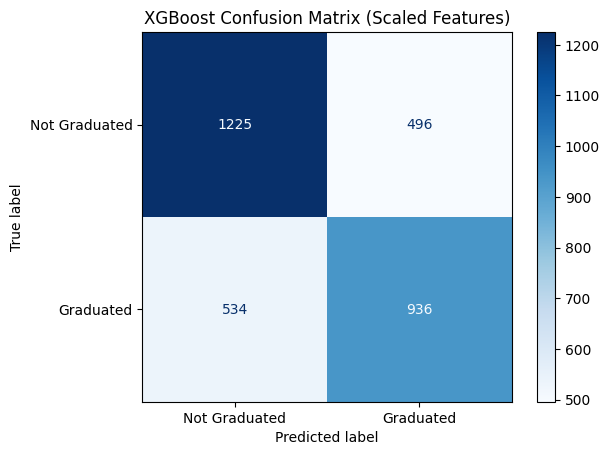

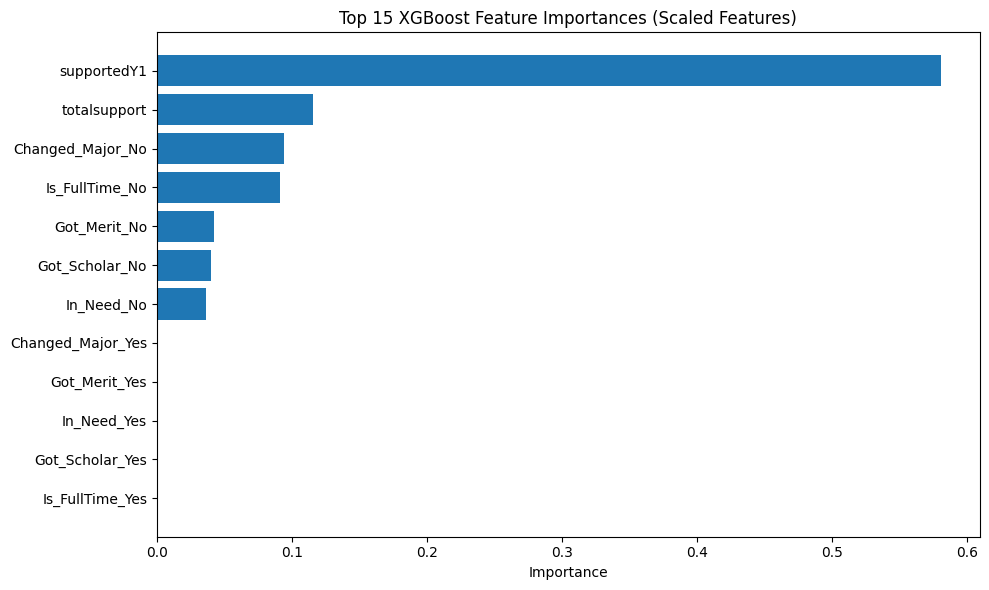

In [33]:
# Train XGBoost model on scaled data
model_scaled, features_scaled = train_xgboost_model(X_train_scaled, y_train_scaled, scale_numeric=True)

# Evaluate the trained model on the scaled test set
evaluate_xgboost_model(model_scaled, X_test_scaled, y_test_scaled, label='scaled')

# Plot and retrieve top feature importances from the scaled model
feat_df_scaled = plot_xgboost_feature_importance(model_scaled, features_scaled, label='scaled')


In [34]:
# Prepare raw (non-scaled) training and testing data using selected features
X_train_raw, X_test_raw, y_train_raw, y_test_raw, preprocessor_raw = prepare_data(
    df=freshman_cleaned_df,
    selected_features=my_features,
    scale_numeric=False
)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:41:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



[XGBoost Raw] Accuracy: 0.6772
[XGBoost Raw] F1 Score: 0.6451
[XGBoost Raw] ROC AUC: 0.7422


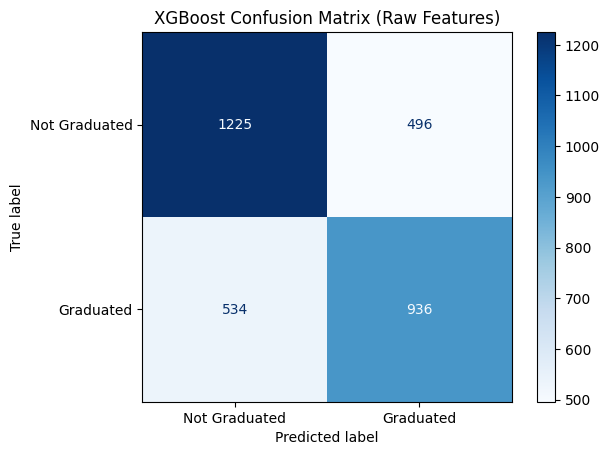

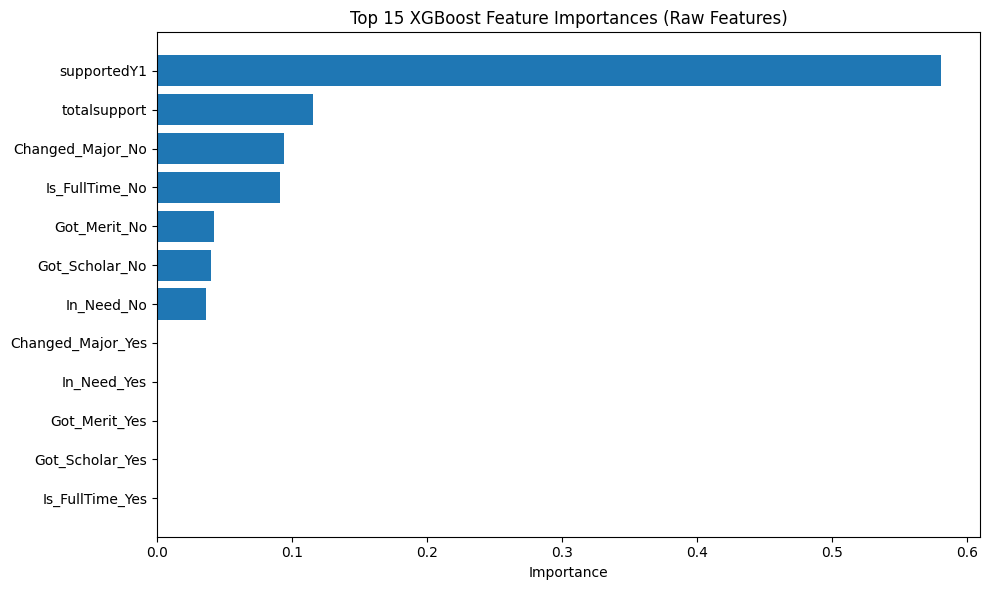

In [35]:
# Train XGBoost model on raw (unscaled) data
model_raw, features_raw = train_xgboost_model(X_train_raw, y_train_raw, scale_numeric=False)

# Evaluate the trained model on the raw test set
evaluate_xgboost_model(model_raw, X_test_raw, y_test_raw, label='raw')

# Plot and retrieve top feature importances from the raw model
feat_df_raw = plot_xgboost_feature_importance(model_raw, features_raw, label='raw')


In [36]:
def xgboost_to_dtreeviz(xgb_model, X_train, y_train, preprocessor, feature_names, label='scaled'):
    """
    Approximates an XGBoost model using a DecisionTreeClassifier and visualizes it using dtreeviz.
    This is helpful for interpreting model logic in a simplified form.

    Parameters:
    - xgb_pipeline: trained sklearn Pipeline containing an XGBClassifier
    - X_train: original training feature DataFrame (before transformation)
    - y_train: training target labels
    - preprocessor: fitted ColumnTransformer used in training
    - feature_names: list of feature names after transformation
    - label: string label used for saving output files (e.g., 'scaled' or 'raw')
    """

    # Apply preprocessing (scaling + one-hot encoding) to the raw training data
    X_trans = preprocessor.fit_transform(X_train)

    # Convert sparse matrix to dense if needed
    if hasattr(X_trans, "toarray"):
        X_trans = X_trans.toarray()

    # Convert preprocessed data to DataFrame with named columns for visualization
    X_df = pd.DataFrame(X_trans, columns=feature_names)

    # Fit a small decision tree on the same transformed data to mimic XGBoost logic
    approx_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
    approx_tree.fit(X_df, y_train)

    # Generate dtreeviz object for visualization
    viz = model(
        approx_tree,            # the approximating DecisionTreeClassifier
        X_df,                   # preprocessed training data
        y_train,                # labels
        feature_names=feature_names,    # feature names after preprocessing
        target_name="Graduated",        # name of the target variable
        class_names={0: "Not Graduated", 1: "Graduated"}  # class labels
    )

    # Render the visualization and convert to SVG string
    render = viz.view()
    svg = render.svg()

    # Define file paths for saving
    svg_path = f"dtreeviz_xgboost_{label}.svg"
    png_path = f"dtreeviz_xgboost_{label}.png"

    # Save the SVG to disk
    with open(svg_path, "w", encoding="utf-8") as f:
        f.write(svg)

    # Convert the SVG to high-resolution PNG
    svg2png(bytestring=svg.encode("utf-8"), write_to=png_path, dpi=300)

    print(f"DTreeViz approximation of XGBoost ({label}) saved to {png_path}")
    display(Image(filename=png_path))


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


DTreeViz approximation of XGBoost (scaled) saved to dtreeviz_xgboost_scaled.png


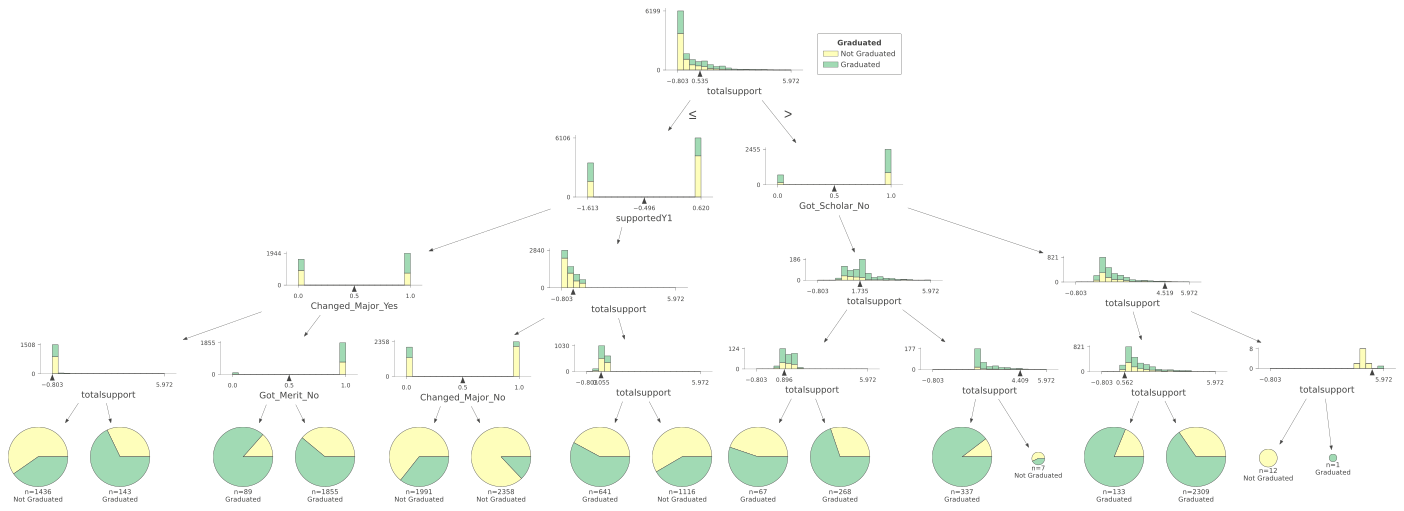

In [37]:
# Visualize a simplified version of the scaled XGBoost model using dtreeviz
xgboost_to_dtreeviz(
    xgb_model=model_scaled,         # Trained XGBoost pipeline using scaled features
    X_train=X_train_scaled,         # Scaled training features (before transformation by preprocessor)
    y_train=y_train_scaled,         # Corresponding target values
    preprocessor=preprocessor_scaled,  # The fitted preprocessing pipeline (StandardScaler + OneHotEncoder)
    feature_names=features_scaled,     # List of final feature names after transformation
    label='scaled'                     # Output label for saving visualizations (e.g., dtreeviz_xgboost_scaled.png)
)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


DTreeViz approximation of XGBoost (raw) saved to dtreeviz_xgboost_raw.png


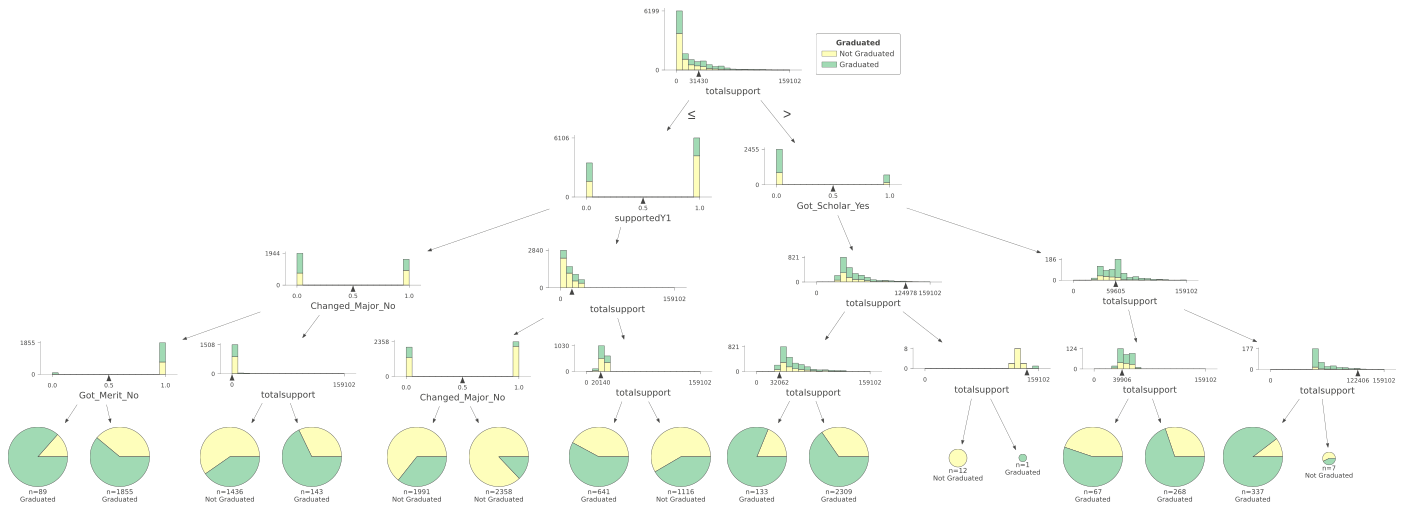

In [38]:
# Visualize a simplified approximation of the raw XGBoost model using a decision tree and dtreeviz
# This helps interpret the decision logic in an easy-to-read tree diagram
xgboost_to_dtreeviz(
    xgb_model=model_raw,           # Trained XGBoost pipeline on raw (unscaled) features
    X_train=X_train_raw,           # Raw training features before transformation
    y_train=y_train_raw,           # Corresponding training labels
    preprocessor=preprocessor_raw, # Preprocessor used in the pipeline (OneHotEncoder + passthrough)
    feature_names=features_raw,    # Feature names after transformation (used in visualization)
    label='raw'
)


In [39]:
print_human_readable_tree(
    xgb_pipeline=model_raw,              # Your trained raw XGBoost pipeline
    X_train=X_train_raw,                 # Raw training features (before transformation)
    y_train=y_train_raw,                 # Corresponding labels
    preprocessor=preprocessor_raw,       # The raw preprocessor (OneHotEncoder + passthrough)
    feature_names=features_raw,          # Cleaned feature names after transformation
    max_depth=4,                         # Keep it consistent with your approximation tree
    label='raw'                          # Label used in the print output
)



[Human Readable Decision Tree Approximation (raw)]:

|--- totalsupport <= 31429.50
|   |--- supportedY1 <= 0.50
|   |   |--- Changed_Major_No <= 0.50
|   |   |   |--- Got_Merit_No <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Got_Merit_No >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Changed_Major_No >  0.50
|   |   |   |--- totalsupport <= 87.50
|   |   |   |   |--- class: 0
|   |   |   |--- totalsupport >  87.50
|   |   |   |   |--- class: 1
|   |--- supportedY1 >  0.50
|   |   |--- totalsupport <= 15936.00
|   |   |   |--- Changed_Major_No <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Changed_Major_No >  0.50
|   |   |   |   |--- class: 0
|   |   |--- totalsupport >  15936.00
|   |   |   |--- totalsupport <= 20140.00
|   |   |   |   |--- class: 1
|   |   |   |--- totalsupport >  20140.00
|   |   |   |   |--- class: 0
|--- totalsupport >  31429.50
|   |--- Got_Scholar_Yes <= 0.50
|   |   |--- totalsupport <= 124977.50
|   |   |   |--- totalsupport <= 32062.00


# **Feature 2**

In [40]:
my_features = [
    'MatricTermdescription', 'MatricAcademicYear', 'MatricGenderIPEDS',
    'MatricIPEDSEthnicity', 'Changed_Major', 'supportedY1',
    'Got_Merit', 'Got_Scholar', 'Is_FullTime', 'totalsupport'
]

In [41]:
# Prepare scaled training and testing data using selected features with numeric scaling enabled
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, preprocessor_scaled = prepare_data(
    df=freshman_cleaned_df,
    selected_features=my_features,
    scale_numeric=True
)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:41:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



[XGBoost Scaled] Accuracy: 0.8474
[XGBoost Scaled] F1 Score: 0.8408
[XGBoost Scaled] ROC AUC: 0.9234


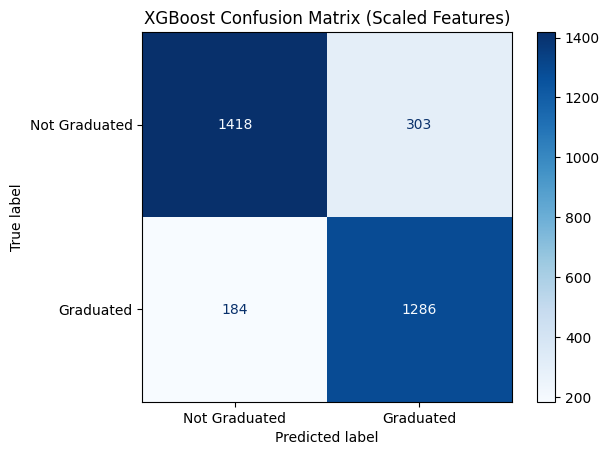

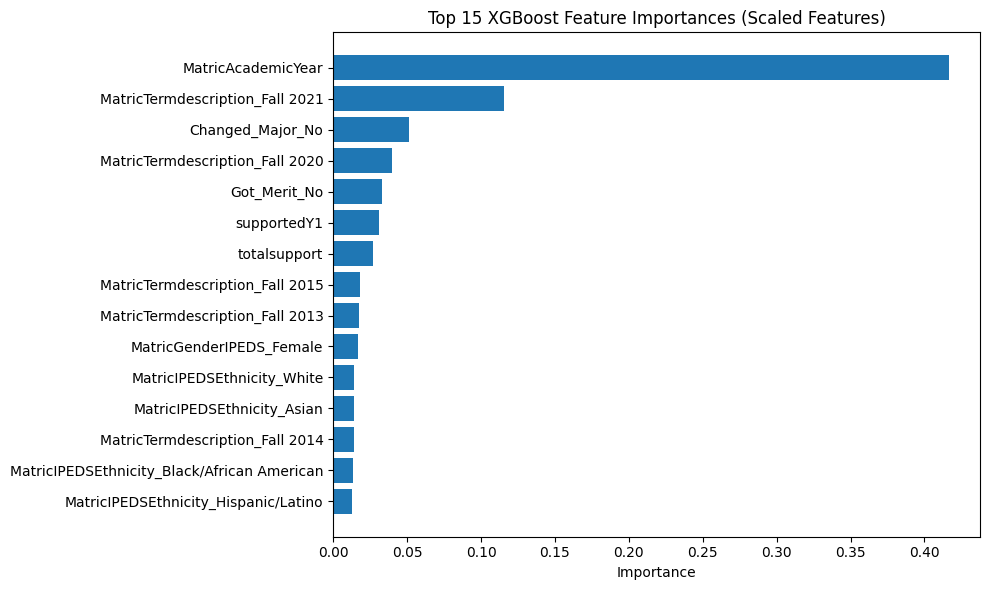

In [42]:

# Train XGBoost model on scaled data
model_scaled, features_scaled = train_xgboost_model(X_train_scaled, y_train_scaled, scale_numeric=True)

# Evaluate the trained model on the scaled test set
evaluate_xgboost_model(model_scaled, X_test_scaled, y_test_scaled, label='scaled')

# Plot and retrieve top feature importances from the scaled model
feat_df_scaled = plot_xgboost_feature_importance(model_scaled, features_scaled, label='scaled')


In [43]:
# Prepare raw (non-scaled) training and testing data using selected features
X_train_raw, X_test_raw, y_train_raw, y_test_raw, preprocessor_raw = prepare_data(
    df=freshman_cleaned_df,
    selected_features=my_features,
    scale_numeric=False
)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:41:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



[XGBoost Raw] Accuracy: 0.8499
[XGBoost Raw] F1 Score: 0.8444
[XGBoost Raw] ROC AUC: 0.9239


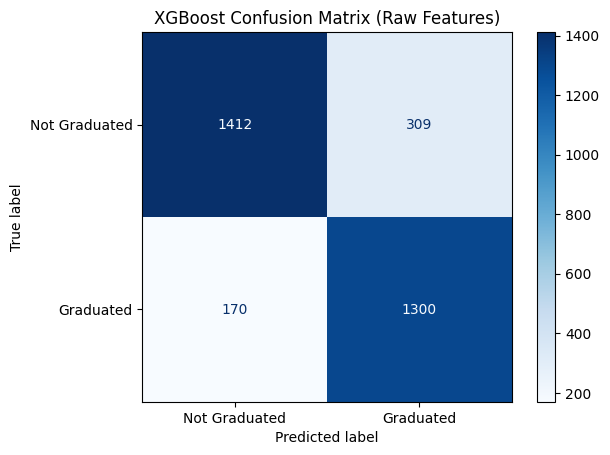

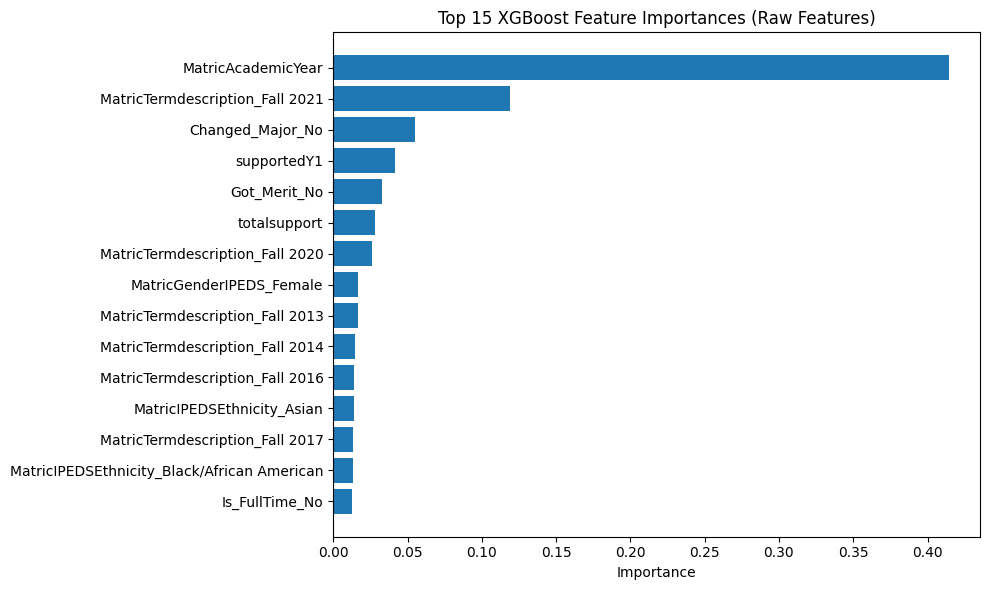

In [44]:
# Train XGBoost model on raw (unscaled) data
model_raw, features_raw = train_xgboost_model(X_train_raw, y_train_raw, scale_numeric=False)

# Evaluate the trained model on the raw test set
evaluate_xgboost_model(model_raw, X_test_raw, y_test_raw, label='raw')

# Plot and retrieve top feature importances from the raw model
feat_df_raw = plot_xgboost_feature_importance(model_raw, features_raw, label='raw')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


DTreeViz approximation of XGBoost (Feature2_scaled) saved to dtreeviz_xgboost_Feature2_scaled.png


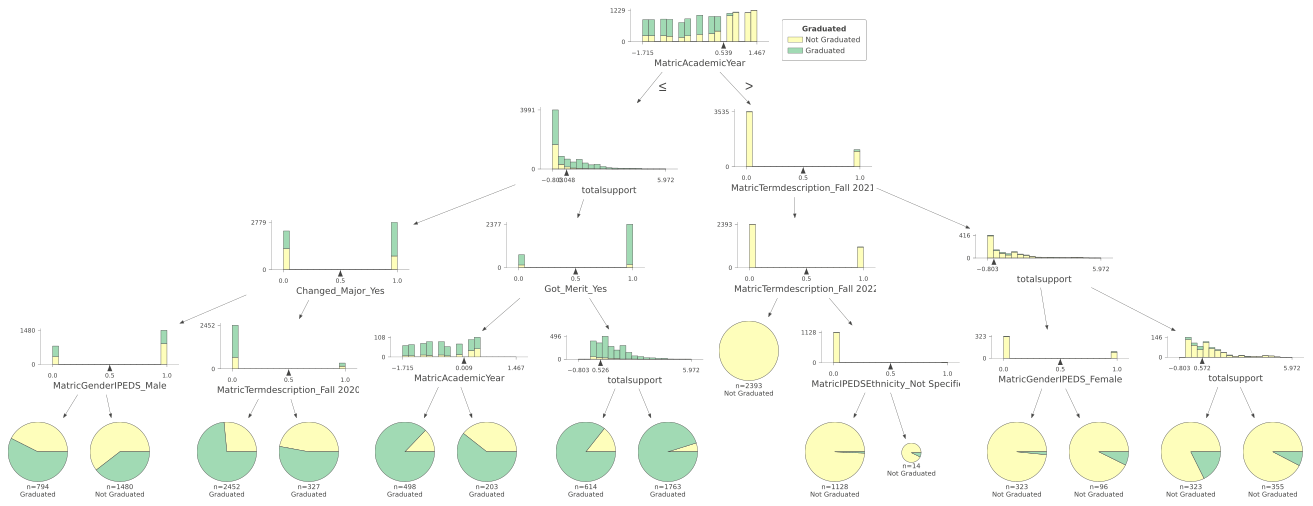

In [45]:
# Visualize a simplified version of the scaled XGBoost model using dtreeviz
xgboost_to_dtreeviz(
    xgb_model=model_scaled,         # Trained XGBoost pipeline using scaled features
    X_train=X_train_scaled,         # Scaled training features (before transformation by preprocessor)
    y_train=y_train_scaled,         # Corresponding target values
    preprocessor=preprocessor_scaled,  # The fitted preprocessing pipeline (StandardScaler + OneHotEncoder)
    feature_names=features_scaled,     # List of final feature names after transformation
    label='Feature2_scaled'                     # Output label for saving visualizations (e.g., dtreeviz_xgboost_scaled.png)
)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


DTreeViz approximation of XGBoost (Feature2_raw) saved to dtreeviz_xgboost_Feature2_raw.png


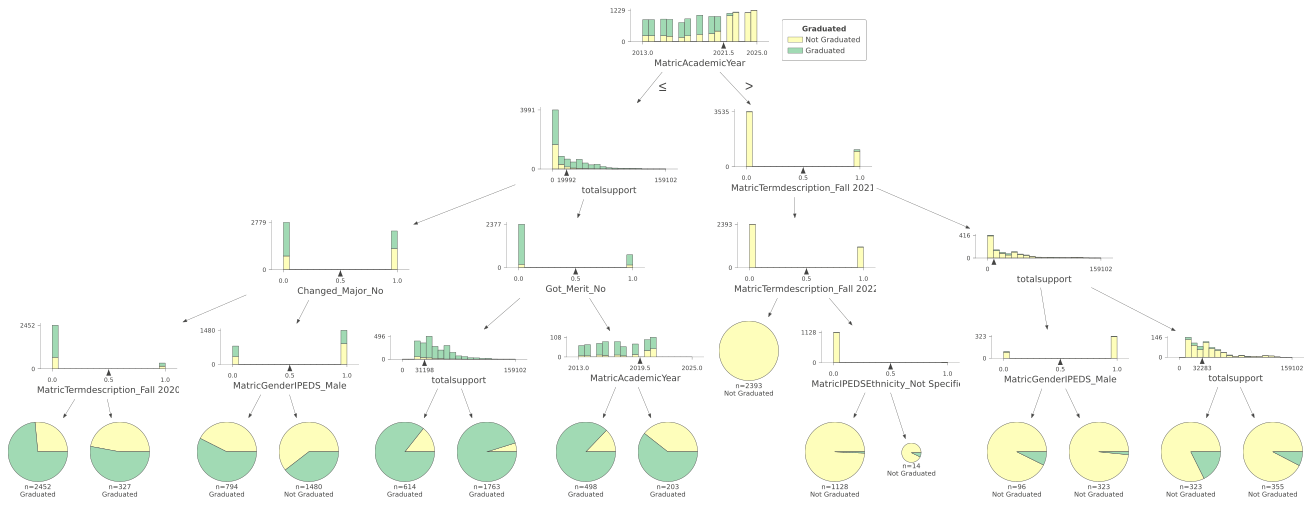

In [46]:

# Visualize a simplified approximation of the raw XGBoost model using a decision tree and dtreeviz
xgboost_to_dtreeviz(
    xgb_model=model_raw,           # Trained XGBoost pipeline on raw (unscaled) features
    X_train=X_train_raw,           # Raw training features before transformation
    y_train=y_train_raw,           # Corresponding training labels
    preprocessor=preprocessor_raw, # Preprocessor used in the pipeline (OneHotEncoder + passthrough)
    feature_names=features_raw,    # Feature names after transformation (used in visualization)
    label='Feature2_raw'
)


# **students who enrolled on or before 2016**

In [47]:
freshman_cleaned_df['MatricYear'] = freshman_cleaned_df['MatricTermdescription'].str.extract(r'(\d{4})').astype(int)

# Keep only students who started in 2016 or earlier
freshman_cleaned_df = freshman_cleaned_df[freshman_cleaned_df['MatricYear'] <= 2016]


In [48]:
my_features = [
     'Changed_Major','supportedY1', 'In_Need', 'Got_Merit', 'Got_Scholar',
    'Is_FullTime', 'totalsupport'
]

In [49]:
# Prepare scaled training and testing data using selected features with numeric scaling enabled
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, preprocessor_scaled = prepare_data(
    df=freshman_cleaned_df,
    selected_features=my_features,
    scale_numeric=True
)

[XGBoost Scaled] Accuracy: 0.7739
[XGBoost Scaled] F1 Score: 0.8632
[XGBoost Scaled] ROC AUC: 0.7657


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:41:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



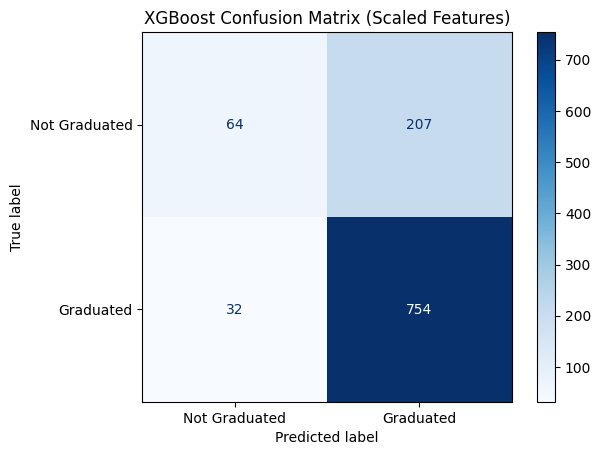

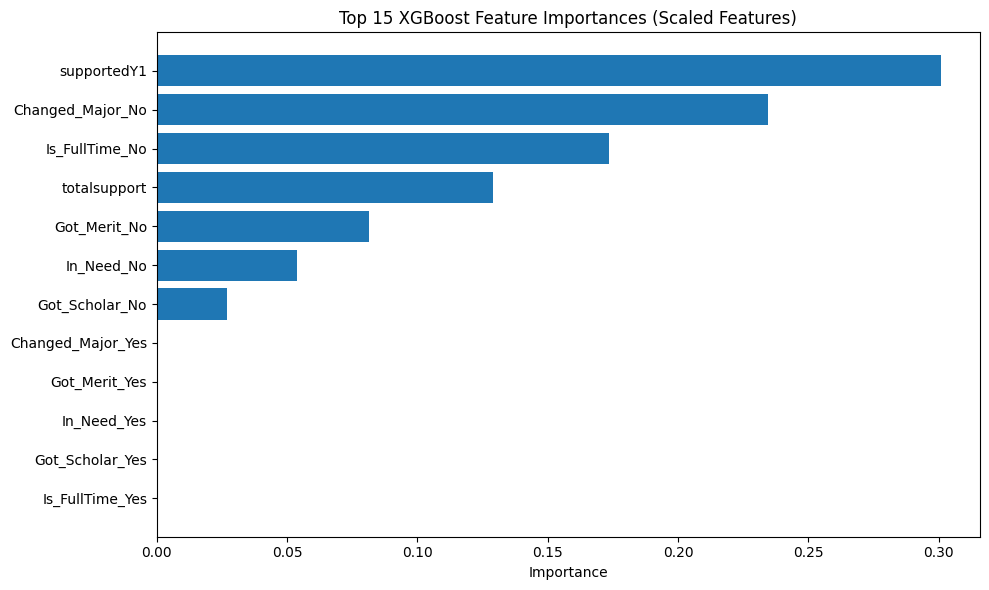

In [50]:

# Train XGBoost model on scaled data
model_scaled, features_scaled = train_xgboost_model(X_train_scaled, y_train_scaled, scale_numeric=True)

# Evaluate the trained model on the scaled test set
evaluate_xgboost_model(model_scaled, X_test_scaled, y_test_scaled, label='scaled')

# Plot and retrieve top feature importances from the scaled model
feat_df_scaled = plot_xgboost_feature_importance(model_scaled, features_scaled, label='scaled')


In [51]:
# Prepare raw (non-scaled) training and testing data using selected features
X_train_raw, X_test_raw, y_train_raw, y_test_raw, preprocessor_raw = prepare_data(
    df=freshman_cleaned_df,
    selected_features=my_features,
    scale_numeric=False
)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:41:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



[XGBoost Raw] Accuracy: 0.7739
[XGBoost Raw] F1 Score: 0.8632
[XGBoost Raw] ROC AUC: 0.7657


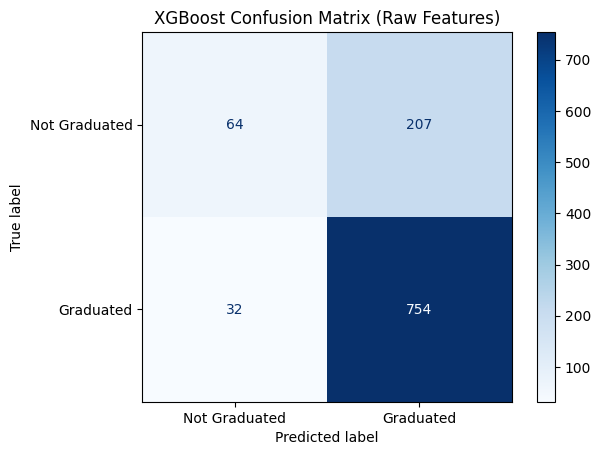

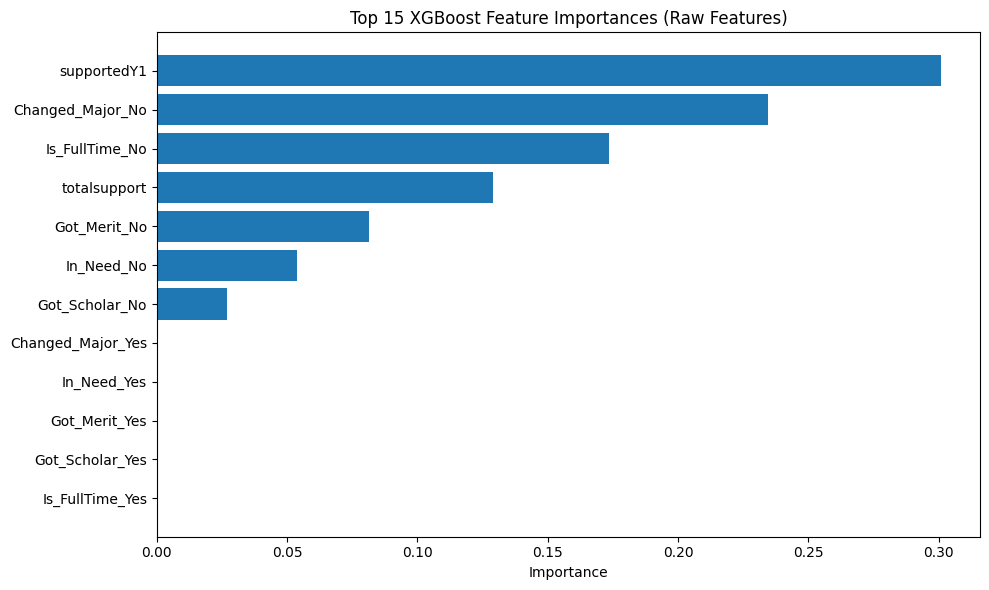

In [52]:
# Train XGBoost model on raw (unscaled) data
model_raw, features_raw = train_xgboost_model(X_train_raw, y_train_raw, scale_numeric=False)

# Evaluate the trained model on the raw test set
evaluate_xgboost_model(model_raw, X_test_raw, y_test_raw, label='raw')

# Plot and retrieve top feature importances from the raw model
feat_df_raw = plot_xgboost_feature_importance(model_raw, features_raw, label='raw')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


DTreeViz approximation of XGBoost (2016_scaled) saved to dtreeviz_xgboost_2016_scaled.png


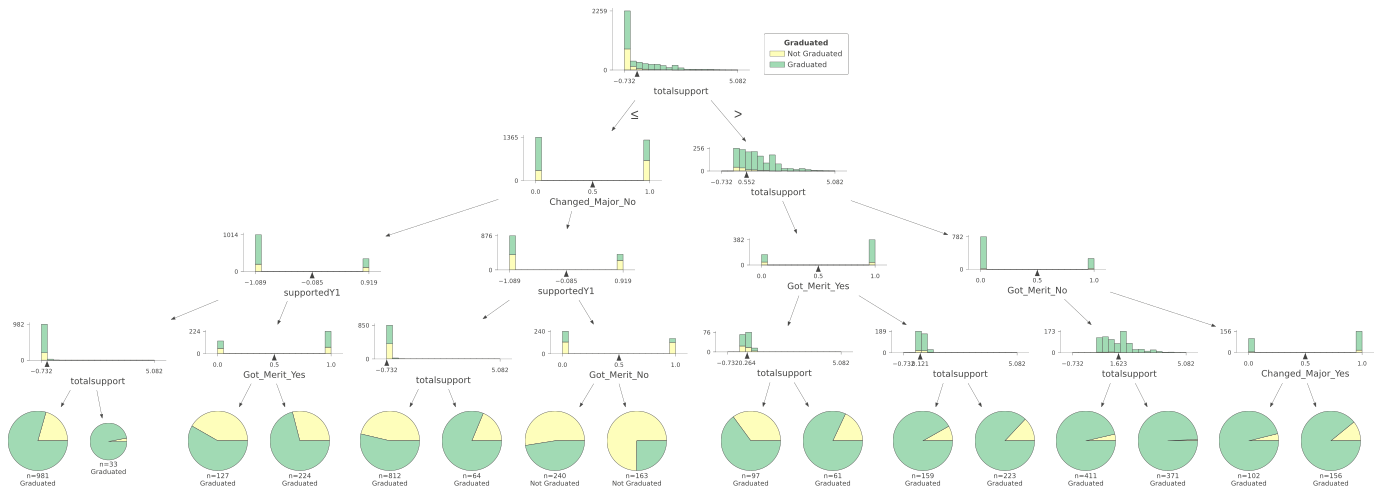

In [53]:
# Visualize a simplified version of the scaled XGBoost model using dtreeviz
xgboost_to_dtreeviz(
    xgb_model=model_scaled,         # Trained XGBoost pipeline using scaled features
    X_train=X_train_scaled,         # Scaled training features (before transformation by preprocessor)
    y_train=y_train_scaled,         # Corresponding target values
    preprocessor=preprocessor_scaled,  # The fitted preprocessing pipeline (StandardScaler + OneHotEncoder)
    feature_names=features_scaled,     # List of final feature names after transformation
    label='2016_scaled'                     # Output label for saving visualizations (e.g., dtreeviz_xgboost_scaled.png)
)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


DTreeViz approximation of XGBoost (2016_raw) saved to dtreeviz_xgboost_2016_raw.png


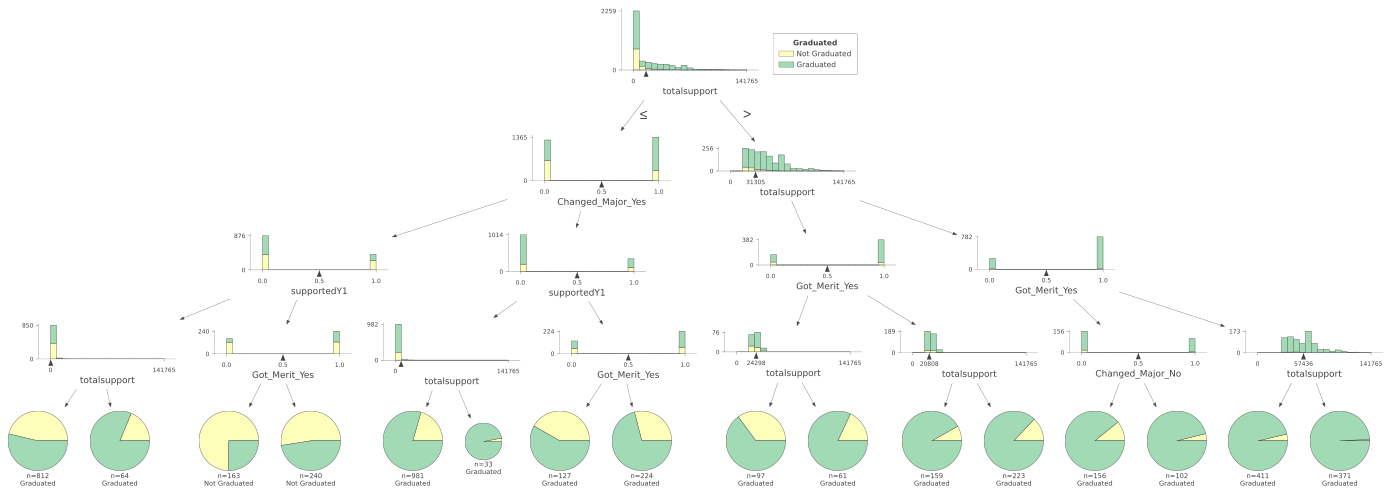

In [54]:
# Visualize a simplified approximation of the raw XGBoost model using a decision tree and dtreeviz
xgboost_to_dtreeviz(
    xgb_model=model_raw,           # Trained XGBoost pipeline on raw (unscaled) features
    X_train=X_train_raw,           # Raw training features before transformation
    y_train=y_train_raw,           # Corresponding training labels
    preprocessor=preprocessor_raw, # Preprocessor used in the pipeline (OneHotEncoder + passthrough)
    feature_names=features_raw,    # Feature names after transformation (used in visualization)
    label='2016_raw'
)

# **Feature2**

In [55]:
my_features = [
    'MatricTermdescription', 'MatricAcademicYear', 'MatricGenderIPEDS',
    'MatricIPEDSEthnicity', 'Changed_Major', 'supportedY1',
    'Got_Merit', 'Got_Scholar', 'Is_FullTime', 'totalsupport'
]

In [56]:
# Prepare scaled training and testing data using selected features with numeric scaling enabled
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, preprocessor_scaled = prepare_data(
    df=freshman_cleaned_df,
    selected_features=my_features,
    scale_numeric=True
)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:42:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



[XGBoost Scaled] Accuracy: 0.7711
[XGBoost Scaled] F1 Score: 0.8532
[XGBoost Scaled] ROC AUC: 0.7756


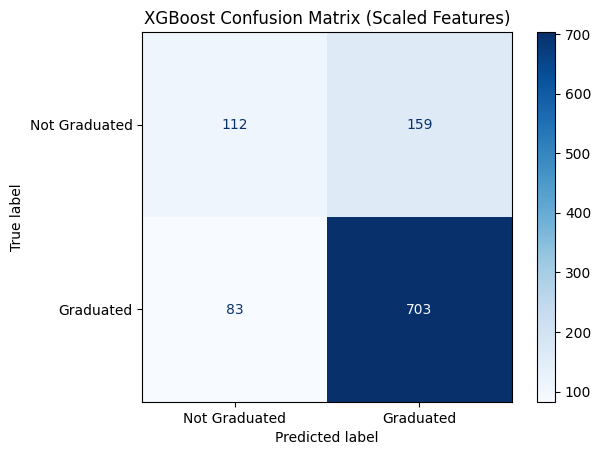

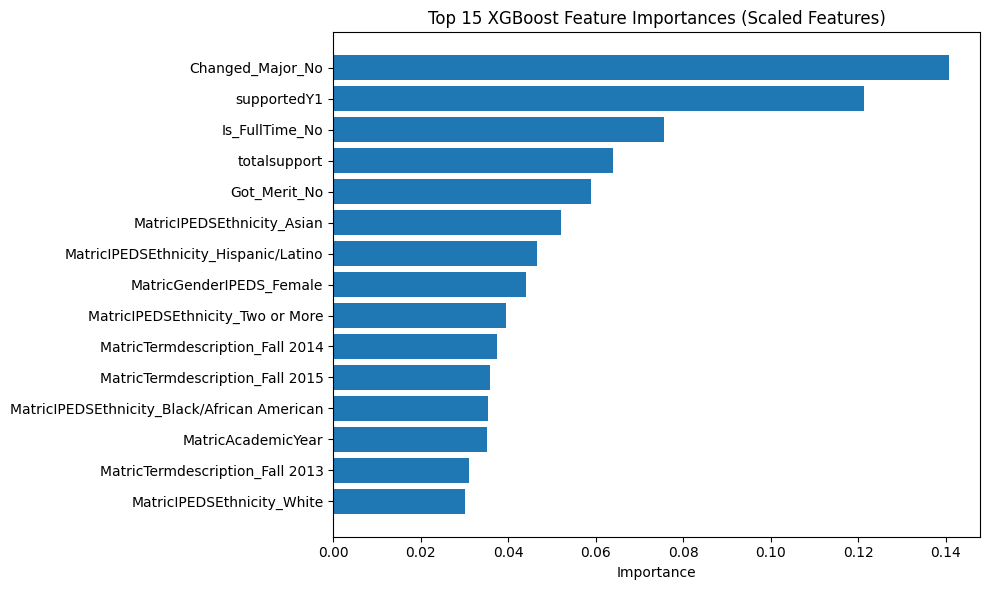

In [57]:

# Train XGBoost model on scaled data
model_scaled, features_scaled = train_xgboost_model(X_train_scaled, y_train_scaled, scale_numeric=True)

# Evaluate the trained model on the scaled test set
evaluate_xgboost_model(model_scaled, X_test_scaled, y_test_scaled, label='scaled')

# Plot and retrieve top feature importances from the scaled model
feat_df_scaled = plot_xgboost_feature_importance(model_scaled, features_scaled, label='scaled')


In [58]:
# Prepare raw (non-scaled) training and testing data using selected features
X_train_raw, X_test_raw, y_train_raw, y_test_raw, preprocessor_raw = prepare_data(
    df=freshman_cleaned_df,
    selected_features=my_features,
    scale_numeric=False
)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:42:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



[XGBoost Raw] Accuracy: 0.7711
[XGBoost Raw] F1 Score: 0.8532
[XGBoost Raw] ROC AUC: 0.7755


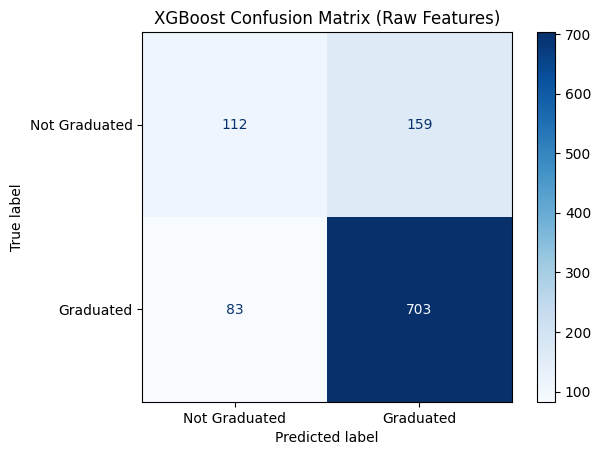

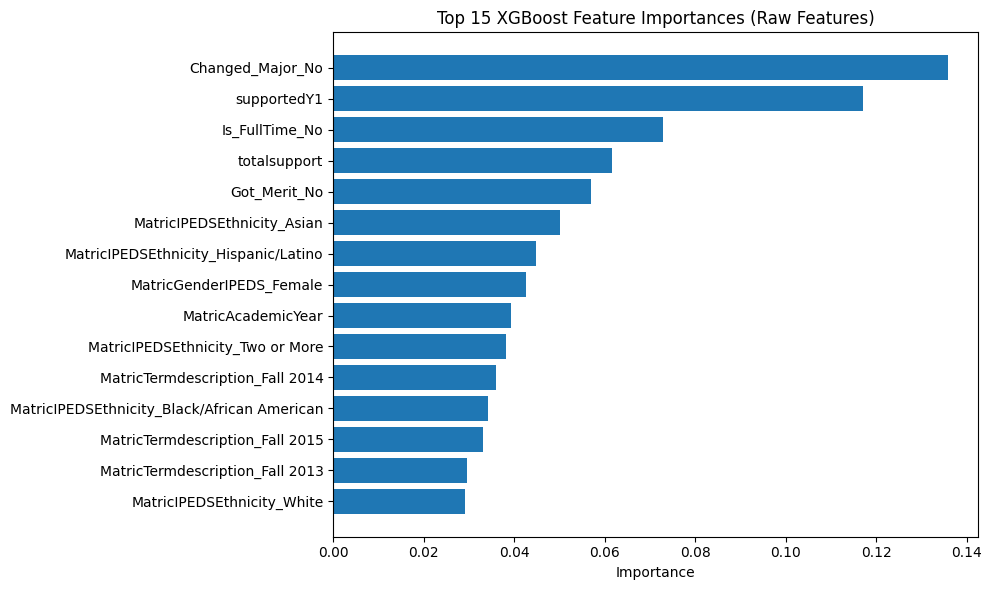

In [59]:
# Train XGBoost model on raw (unscaled) data
model_raw, features_raw = train_xgboost_model(X_train_raw, y_train_raw, scale_numeric=False)

# Evaluate the trained model on the raw test set
evaluate_xgboost_model(model_raw, X_test_raw, y_test_raw, label='raw')

# Plot and retrieve top feature importances from the raw model
feat_df_raw = plot_xgboost_feature_importance(model_raw, features_raw, label='raw')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


DTreeViz approximation of XGBoost (Feature2_2016_scaled) saved to dtreeviz_xgboost_Feature2_2016_scaled.png


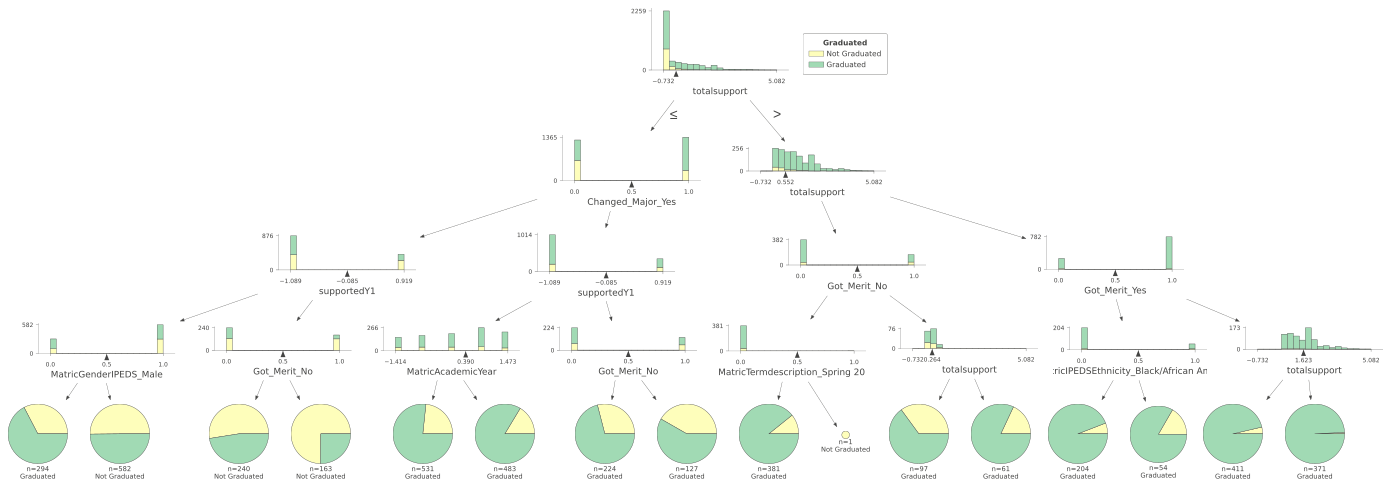

In [60]:
# Visualize a simplified version of the scaled XGBoost model using dtreeviz
xgboost_to_dtreeviz(
    xgb_model=model_scaled,         # Trained XGBoost pipeline using scaled features
    X_train=X_train_scaled,         # Scaled training features (before transformation by preprocessor)
    y_train=y_train_scaled,         # Corresponding target values
    preprocessor=preprocessor_scaled,  # The fitted preprocessing pipeline (StandardScaler + OneHotEncoder)
    feature_names=features_scaled,     # List of final feature names after transformation
    label='Feature2_2016_scaled'                     # Output label for saving visualizations (e.g., dtreeviz_xgboost_scaled.png)
)


In [61]:
from sklearn.tree import DecisionTreeClassifier, export_text
import pandas as pd

def print_human_readable_tree(xgb_pipeline, X_train, y_train, preprocessor, feature_names, max_depth=4, label='tree'):
    """
    Trains a simplified DecisionTreeClassifier to approximate the XGBoost model logic and
    prints the tree in a human-readable format (text-based).

    Parameters:
    - xgb_pipeline: Trained XGBoost pipeline (only used for consistency)
    - X_train: Raw training DataFrame (before preprocessing)
    - y_train: Target labels
    - preprocessor: Preprocessing pipeline (fitted or to be fitted)
    - feature_names: List of final transformed feature names
    - max_depth: Maximum depth of the approximating decision tree
    - label: Optional label for title/identification
    """

    # Apply preprocessing to training data
    X_trans = preprocessor.fit_transform(X_train)

    # Convert sparse matrix to dense array if needed
    if hasattr(X_trans, "toarray"):
        X_trans = X_trans.toarray()

    # Build DataFrame from transformed features
    X_df = pd.DataFrame(X_trans, columns=feature_names)

    # Fit simplified Decision Tree
    approx_tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    approx_tree.fit(X_df, y_train)

    # Generate and print the human-readable tree
    tree_text = export_text(approx_tree, feature_names=feature_names)
    print(f"\n[Human Readable Decision Tree Approximation ({label})]:\n")
    print(tree_text)


In [62]:
print_human_readable_tree(
    xgb_pipeline=model_raw,              # Your trained raw XGBoost pipeline
    X_train=X_train_raw,                 # Raw training features (before transformation)
    y_train=y_train_raw,                 # Corresponding labels
    preprocessor=preprocessor_raw,       # The raw preprocessor (OneHotEncoder + passthrough)
    feature_names=features_raw,          # Cleaned feature names after transformation
    max_depth=4,                         # Keep it consistent with your approximation tree
    label='raw'                          # Label used in the print output
)



[Human Readable Decision Tree Approximation (raw)]:

|--- totalsupport <= 15980.00
|   |--- Changed_Major_Yes <= 0.50
|   |   |--- supportedY1 <= 0.50
|   |   |   |--- MatricGenderIPEDS_Female <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- MatricGenderIPEDS_Female >  0.50
|   |   |   |   |--- class: 1
|   |   |--- supportedY1 >  0.50
|   |   |   |--- Got_Merit_Yes <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Got_Merit_Yes >  0.50
|   |   |   |   |--- class: 0
|   |--- Changed_Major_Yes >  0.50
|   |   |--- supportedY1 <= 0.50
|   |   |   |--- MatricAcademicYear <= 2015.50
|   |   |   |   |--- class: 1
|   |   |   |--- MatricAcademicYear >  2015.50
|   |   |   |   |--- class: 1
|   |   |--- supportedY1 >  0.50
|   |   |   |--- Got_Merit_No <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Got_Merit_No >  0.50
|   |   |   |   |--- class: 1
|--- totalsupport >  15980.00
|   |--- totalsupport <= 31305.00
|   |   |--- Got_Merit_Yes <= 0.50
|   |   |   |--- totalsuppo